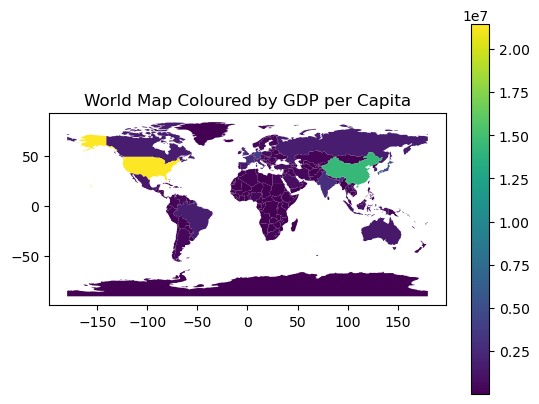

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load example geospatial dataset
world = gpd.read_file('/vsicurl/https://github.com/Explore-AI/Public-Data/raw/master/naturalearth_lowres/ne_110m_admin_0_countries.shp')

# Plot the world map, colouring the countries based on their GDP per capita.
world.plot(column='GDP_MD', legend=True)
plt.title("World Map Coloured by GDP per Capita")
plt.show()

In [2]:
# Load geospatial dataset
world = gpd.read_file('/vsicurl/https://github.com/Explore-AI/Public-Data/raw/master/naturalearth_lowres/ne_110m_admin_0_countries.shp')
world.columns.tolist()

['featurecla',
 'scalerank',
 'LABELRANK',
 'SOVEREIGNT',
 'SOV_A3',
 'ADM0_DIF',
 'LEVEL',
 'TYPE',
 'TLC',
 'ADMIN',
 'ADM0_A3',
 'GEOU_DIF',
 'GEOUNIT',
 'GU_A3',
 'SU_DIF',
 'SUBUNIT',
 'SU_A3',
 'BRK_DIFF',
 'NAME',
 'NAME_LONG',
 'BRK_A3',
 'BRK_NAME',
 'BRK_GROUP',
 'ABBREV',
 'POSTAL',
 'FORMAL_EN',
 'FORMAL_FR',
 'NAME_CIAWF',
 'NOTE_ADM0',
 'NOTE_BRK',
 'NAME_SORT',
 'NAME_ALT',
 'MAPCOLOR7',
 'MAPCOLOR8',
 'MAPCOLOR9',
 'MAPCOLOR13',
 'POP_EST',
 'POP_RANK',
 'POP_YEAR',
 'GDP_MD',
 'GDP_YEAR',
 'ECONOMY',
 'INCOME_GRP',
 'FIPS_10',
 'ISO_A2',
 'ISO_A2_EH',
 'ISO_A3',
 'ISO_A3_EH',
 'ISO_N3',
 'ISO_N3_EH',
 'UN_A3',
 'WB_A2',
 'WB_A3',
 'WOE_ID',
 'WOE_ID_EH',
 'WOE_NOTE',
 'ADM0_ISO',
 'ADM0_DIFF',
 'ADM0_TLC',
 'ADM0_A3_US',
 'ADM0_A3_FR',
 'ADM0_A3_RU',
 'ADM0_A3_ES',
 'ADM0_A3_CN',
 'ADM0_A3_TW',
 'ADM0_A3_IN',
 'ADM0_A3_NP',
 'ADM0_A3_PK',
 'ADM0_A3_DE',
 'ADM0_A3_GB',
 'ADM0_A3_BR',
 'ADM0_A3_IL',
 'ADM0_A3_PS',
 'ADM0_A3_SA',
 'ADM0_A3_EG',
 'ADM0_A3_MA',
 'ADM0_A3_PT

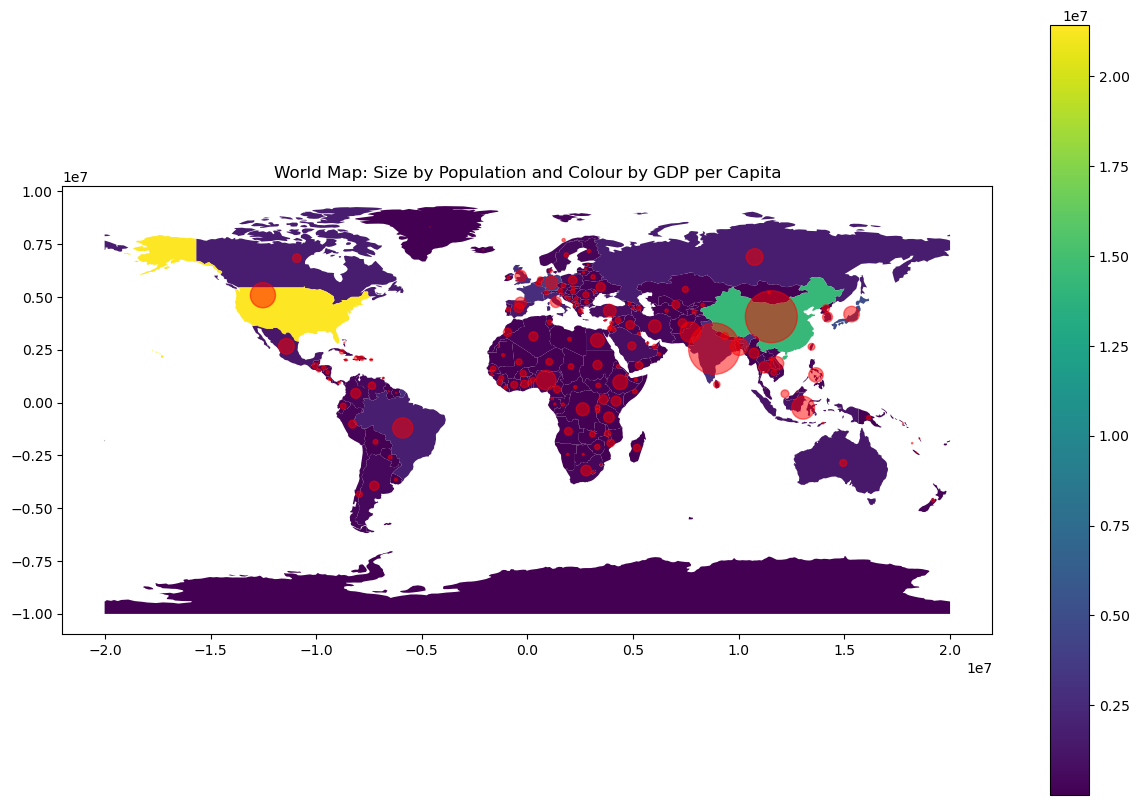

In [3]:
# Reproject geometries to a projected CRS
world = world.to_crs('EPSG:3786')

# Calculate the centre of each country for the scatter plot
world['centroid'] = world.geometry.centroid
world['centroid_lon'] = world.centroid.x
world['centroid_lat'] = world.centroid.y

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map colouring countries by GDP per capita
world.plot(column='GDP_MD', ax=ax, legend=True, cmap='viridis')

# Overlay a scatter plot where the size of each point is proportional to the population
plt.scatter(
    world['centroid_lon'],
    world['centroid_lat'],
    s=world['POP_EST'] / 1e6,  # Size of markers
    color='red',
    alpha=0.5
)

plt.title("World Map: Size by Population and Colour by GDP per Capita")
plt.show()

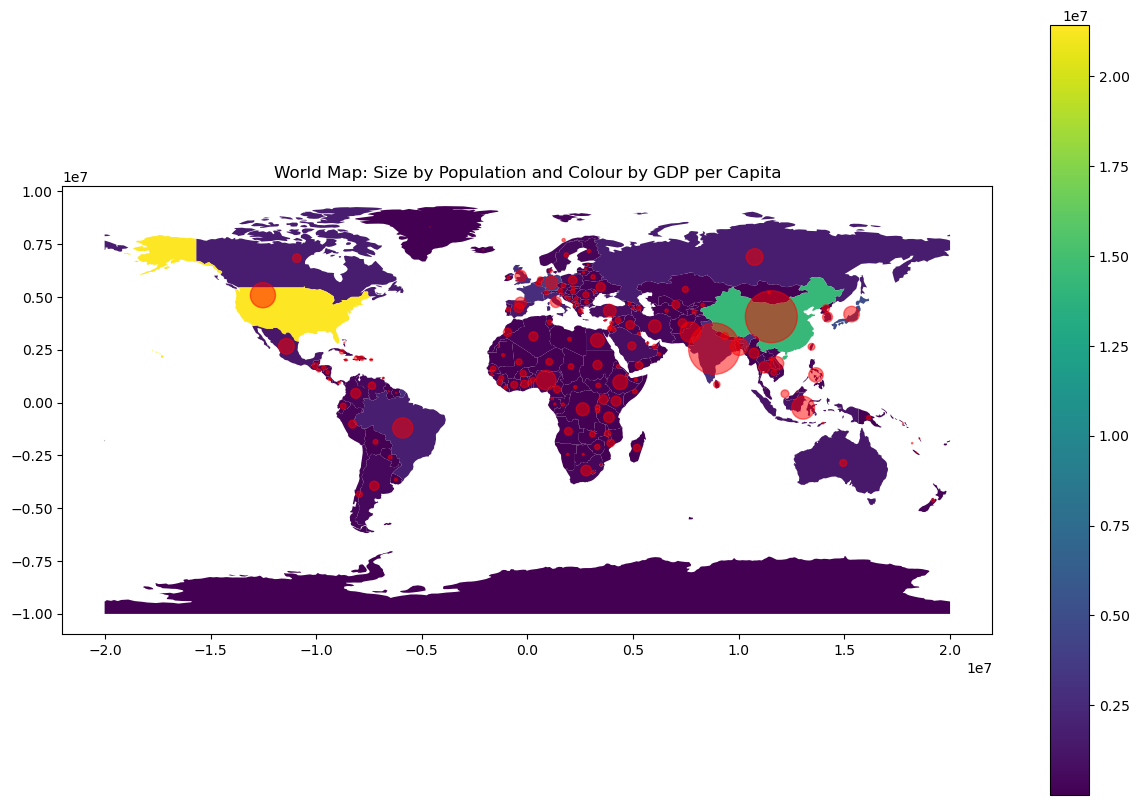

In [4]:
from sklearn.cluster import KMeans
# Reproject geometries to a projected CRS
world = world.to_crs('EPSG:3786')

# Calculate the centre of each country for the scatter plot
world['centroid'] = world.geometry.centroid
world['centroid_lon'] = world.centroid.x
world['centroid_lat'] = world.centroid.y

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map colouring countries by GDP per capita
world.plot(column='GDP_MD', ax=ax, legend=True, cmap='viridis')

# Overlay a scatter plot where the size of each point is proportional to the population
plt.scatter(
    world['centroid_lon'],
    world['centroid_lat'],
    s=world['POP_EST'] / 1e6,  # Size of markers
    color='red',
    alpha=0.5
)

plt.title("World Map: Size by Population and Colour by GDP per Capita")
plt.show()

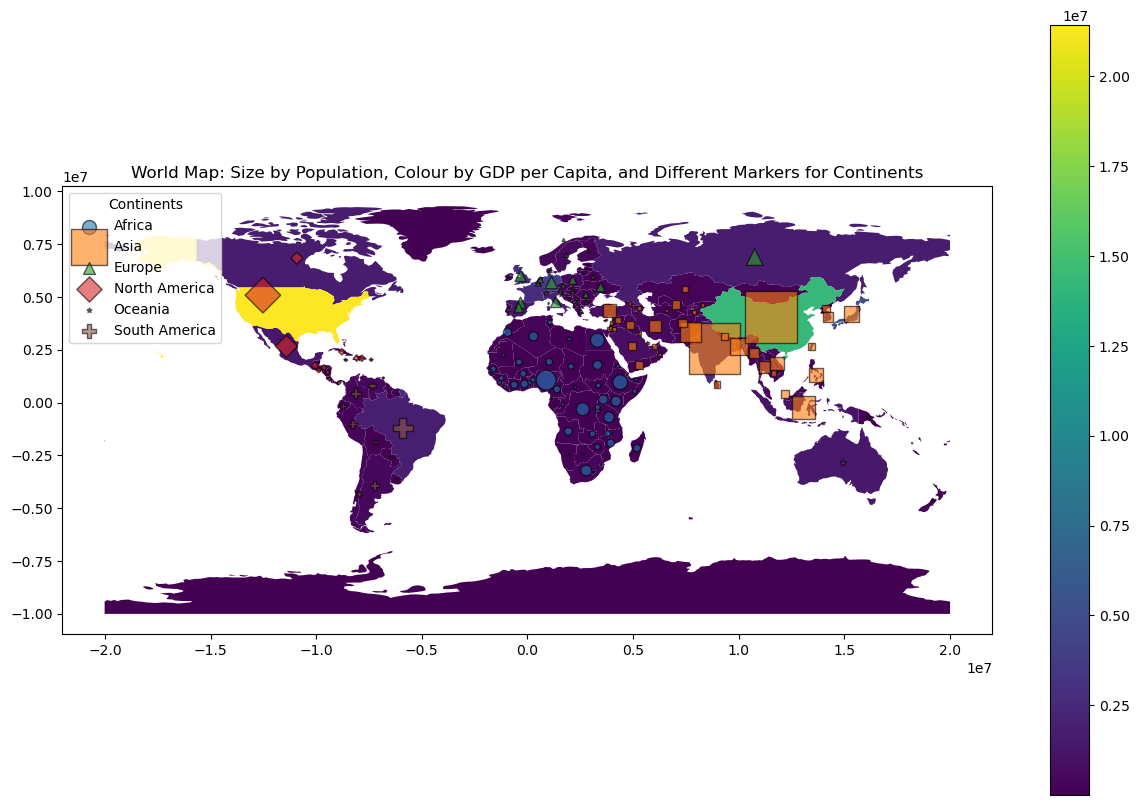

In [5]:
# Marker shapes for continents
marker_shapes = {'Africa': 'o', 'Asia': 's', 'Europe': '^', 'North America': 'D', 'Oceania': '*', 'South America': 'P'}

# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Plot the world map colouring countries by GDP per capita
world.plot(column='GDP_MD', ax=ax, legend=True, cmap='viridis')

# Overlay a scatter plot where the size of each point is proportional to the population and marker shapes for continents
for continent, marker in marker_shapes.items():
    subset = world[world['CONTINENT'] == continent]
    plt.scatter(
        subset['centroid_lon'],
        subset['centroid_lat'],
        s=subset['POP_EST'] / 1e6,
        marker=marker,
        label=continent,
        alpha=0.6,
        edgecolors='k'
    )

plt.legend(title="Continents")
plt.title("World Map: Size by Population, Colour by GDP per Capita, and Different Markers for Continents")
plt.show()